# Masked pure-noise contamination/noise limit sweep

This notebook probes how the linear and robust GD IMF decompositions degrade as Gaussian noise, contamination probability, and contamination magnitude increase when contamination-mask points are replaced by pure noise (`Y_i = Eps_i`). Unmasked observations remain the clean signal plus Gaussian noise. It keeps the real-vs-calculated framing from [gd_imf_real_vs_calculated_noise_only.ipynb](gd_imf_real_vs_calculated_noise_only.ipynb): each calculated IMF is compared against the matching clean-reference IMF for the same method.


## Experiment plan

- Sweep `sigma`, contamination probability `p`, and exponential contamination scale on a deterministic coarse grid under the masked pure-noise contamination model.
- Use coupled deterministic noise draws across the grid so slices reflect parameter changes rather than fresh randomness.
- Use `H = 2 sigma` for robust GD and precompute clean robust references once per sigma.
- Visualize error surfaces, robust/linear ratios, baseline-relative degradation, and representative detailed cases.
- Treat every limit as descriptive: the notebook shows degradation and robust/linear ratios, not a binary pass/fail rule.


## Setup


In [1]:
import os
import time
from itertools import product
from numpy.lib.stride_tricks import sliding_window_view
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from IPython.display import display


rng = np.random.default_rng(42)

SQRT_2 = np.sqrt(2.0)
SQRT_2_OVER_PI = np.sqrt(2.0 / np.pi)
DEFAULT_MAX_WORKERS = min(12, os.cpu_count() or 1)

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DEFAULT_MAX_WORKERS


12

## Signal, masked observation model, and window schedule


In [2]:
def odd_ceiling(value):
    size = int(np.ceil(value))
    if size % 2 == 0:
        size += 1
    return max(1, size)


def nearest_odd(value):
    rounded = int(np.round(value))
    if rounded % 2 == 1:
        return max(1, rounded)

    lower = max(1, rounded - 1)
    upper = rounded + 1
    if abs(value - lower) <= abs(upper - value):
        return lower
    return upper


def make_window_schedule(n, factor=np.sqrt(2.0), min_window_size=31):
    if n <= 0:
        raise ValueError("n must be positive")
    if factor <= 1:
        raise ValueError("factor must be larger than 1")

    first = odd_ceiling(n / 2)
    if first > n:
        first = n if n % 2 == 1 else n - 1

    min_size = nearest_odd(min_window_size)
    if min_size > first:
        return [first]

    sizes = [first]
    current = first

    while current > min_size:
        candidate = nearest_odd(current / factor)
        candidate = min(candidate, current - 2)
        if candidate % 2 == 0:
            candidate -= 1
        if candidate < min_size:
            candidate = min_size

        sizes.append(candidate)
        current = candidate

    return sizes


TARGET_SIGNAL_STD = 0.38545431761087123


def gen_signal(t, seed=2026, target_std=TARGET_SIGNAL_STD):
    t = np.asarray(t, dtype=float)
    if t.ndim != 1 or len(t) < 2:
        raise ValueError("t must be a one-dimensional array with at least two points")
    if target_std <= 0:
        raise ValueError("target_std must be positive")

    rng = np.random.default_rng(seed)
    t_span = np.ptp(t)
    if t_span <= 0:
        raise ValueError("t must span a positive interval")
    u = (t - t.min()) / t_span

    def center_and_scale(values, scale):
        values = np.asarray(values, dtype=float) - np.mean(values)
        values_std = np.std(values)
        if values_std == 0:
            return values
        return scale * values / values_std

    baseline = np.zeros_like(u)
    for harmonic in range(1, 6):
        amplitude = rng.normal(scale=1.0 / harmonic)
        phase = rng.uniform(0.0, 2.0 * np.pi)
        baseline += amplitude * np.sin(2.0 * np.pi * harmonic * u + phase)
    baseline = center_and_scale(baseline, scale=0.36)

    amplitude_envelope = 0.75 + 0.35 * np.sin(2.0 * np.pi * (1.3 * u + 0.08) + rng.uniform(0.0, 2.0 * np.pi))
    chirp_phase = 2.0 * np.pi * (2.2 * u + 5.8 * u ** 2 + 0.35 * np.sin(2.0 * np.pi * u + rng.uniform(0.0, 2.0 * np.pi)))
    chirp = center_and_scale(amplitude_envelope * np.sin(chirp_phase), scale=0.22)

    transients = np.zeros_like(u)
    for center, width, height in zip(
        rng.uniform(0.08, 0.92, size=8),
        rng.uniform(0.008, 0.04, size=8),
        rng.normal(0.0, 1.0, size=8),
    ):
        transients += height * np.exp(-0.5 * ((u - center) / width) ** 2)
    transients = center_and_scale(transients, scale=0.30)

    texture_raw = rng.normal(size=len(u))
    texture_radius = max(3, nearest_odd(0.02 * len(u)) // 2)
    texture_offsets = np.arange(-texture_radius, texture_radius + 1)
    texture_kernel = np.exp(-0.5 * (texture_offsets / max(1.0, texture_radius / 2.5)) ** 2)
    texture_kernel = texture_kernel / texture_kernel.sum()
    texture = np.convolve(texture_raw, texture_kernel, mode="same")
    texture = center_and_scale(texture, scale=0.08)

    components = {
        "baseline": baseline,
        "chirp": chirp,
        "transients": transients,
        "texture": texture,
    }
    x = sum(components.values())
    x_std = np.std(x)
    if x_std == 0:
        raise ValueError("generated signal has zero standard deviation")

    rescale = target_std / x_std
    components = {name: component * rescale for name, component in components.items()}
    x = sum(components.values())
    return x, components


def generate_observation(
    x,
    sigma=0.1,
    contamination_prob=0.05,
    contamination_scale=0.1,
    centered_contamination=False,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    gaussian_noise = rng.normal(loc=0.0, scale=sigma, size=len(x))
    contamination_mask = rng.random(len(x)) < contamination_prob
    exponential_noise = rng.exponential(scale=contamination_scale, size=len(x))

    if centered_contamination:
        exponential_noise = exponential_noise - contamination_scale

    contamination = contamination_mask * exponential_noise

    sign = rng.choice([-1, 1], size=len(x))
    contamination *= sign

    y = np.where(
        contamination_mask,
        gaussian_noise + contamination,
        np.asarray(x, dtype=float) + gaussian_noise,
    )

    return y, {
        "gaussian_noise": gaussian_noise,
        "contamination": contamination,
        "contamination_mask": contamination_mask,
    }



CURRENT_SIGMA = 0.4
CURRENT_CONTAMINATION_PROB = 0.2
CURRENT_CONTAMINATION_SCALE = 2.0 * CURRENT_SIGMA
CURRENT_REPEAT = 0

n = 1000
t = np.linspace(0.0, 1.0, n)
sigma = CURRENT_SIGMA
H = 2 * sigma

window_sizes = make_window_schedule(n, factor=np.sqrt(2.0), min_window_size=31)
x_clean, true_components = gen_signal(t)
component_sum = sum(true_components.values())

assert x_clean.shape == t.shape
assert all(component.shape == t.shape for component in true_components.values())
assert np.all(np.isfinite(x_clean))
assert all(np.all(np.isfinite(component)) for component in true_components.values())
assert np.allclose(x_clean, component_sum)
assert np.isclose(x_clean.std(), TARGET_SIGNAL_STD, rtol=1e-10, atol=1e-12)

assert window_sizes[0] == 501
assert all(size % 2 == 1 for size in window_sizes)
assert all(left > right for left, right in zip(window_sizes, window_sizes[1:]))
assert min(window_sizes) >= 31

window_schedule_df = pd.DataFrame({
    "stage": np.arange(1, len(window_sizes) + 1),
    "window_size": window_sizes,
    "radius": [size // 2 for size in window_sizes],
    "relative_width": np.array(window_sizes) / n,
})

window_schedule_df


,stage,window_size,radius,relative_width
0,1,501,250,0.501
1,2,355,177,0.355
2,3,251,125,0.251
3,4,177,88,0.177
4,5,125,62,0.125
5,6,89,44,0.089
6,7,63,31,0.063
7,8,45,22,0.045
8,9,31,15,0.031


## Kernel, robust contrast, and lookup grid


In [3]:
def epanechnikov_weights(window_size):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    radius = window_size // 2
    if radius == 0:
        return np.array([1.0])

    offsets = np.arange(-radius, radius + 1)
    u = offsets / radius
    weights = 0.75 * np.maximum(0.0, 1.0 - np.abs(u)) ** 2
    return weights / weights.sum()


def erf_approx(x):
    x = np.asarray(x, dtype=float)
    sign = np.sign(x)
    ax = np.abs(x)

    p = 0.3275911
    a1 = 0.254829592
    a2 = -0.284496736
    a3 = 1.421413741
    a4 = -1.453152027
    a5 = 1.061405429

    z = 1.0 / (1.0 + p * ax)
    poly = (((((a5 * z + a4) * z + a3) * z + a2) * z + a1) * z)
    return sign * (1.0 - poly * np.exp(-(ax ** 2)))


def exact_score(residual, H):
    if H <= 0:
        raise ValueError("H must be positive")
    return erf_approx(np.asarray(residual, dtype=float) / (SQRT_2 * H))


def exact_exp(residual, H):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return np.exp(-0.5 * z ** 2)


def smooth_abs_rho_exact(residual, H):
    residual = np.asarray(residual, dtype=float)
    return residual * exact_score(residual, H) + SQRT_2_OVER_PI * H * exact_exp(residual, H)


def make_lookup_grid(zmax=8.0, num=4097):
    if zmax <= 0:
        raise ValueError("zmax must be positive")
    if num < 3:
        raise ValueError("num must be at least 3")

    z_grid = np.linspace(-zmax, zmax, num)
    return {
        "z": z_grid,
        "score": erf_approx(z_grid / SQRT_2),
        "exp": np.exp(-0.5 * z_grid ** 2),
        "zmax": float(zmax),
        "num": int(num),
    }


def _interp_like(values, x_grid, y_grid, left, right):
    values = np.asarray(values, dtype=float)
    flat = np.interp(values.ravel(), x_grid, y_grid, left=left, right=right)
    return flat.reshape(values.shape)


def lookup_score(residual, H, grid):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return _interp_like(z, grid["z"], grid["score"], left=-1.0, right=1.0)


def lookup_exp(residual, H, grid):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return _interp_like(z, grid["z"], grid["exp"], left=0.0, right=0.0)


def smooth_abs_rho_lookup(residual, H, grid):
    residual = np.asarray(residual, dtype=float)
    return residual * lookup_score(residual, H, grid) + SQRT_2_OVER_PI * H * lookup_exp(residual, H, grid)


lookup_grid = make_lookup_grid(zmax=8.0, num=4097)

for size in window_sizes:
    weights = epanechnikov_weights(size)
    assert np.all(weights >= 0)
    assert np.isclose(weights.sum(), 1.0)

z_validation = np.linspace(-lookup_grid["zmax"], lookup_grid["zmax"], 20001)
residual_validation = z_validation * H

score_max_error = np.max(np.abs(
    lookup_score(residual_validation, H, lookup_grid)
    - exact_score(residual_validation, H)
))
exp_max_error = np.max(np.abs(
    lookup_exp(residual_validation, H, lookup_grid)
    - exact_exp(residual_validation, H)
))
tail_exp_at_zmax = np.exp(-0.5 * lookup_grid["zmax"] ** 2)

assert score_max_error < 5e-4
assert exp_max_error < 5e-4
assert tail_exp_at_zmax < 1e-12

pd.DataFrame([
    {"quantity": "score max abs error", "value": score_max_error},
    {"quantity": "exponent max abs error", "value": exp_max_error},
    {"quantity": "exp(-zmax^2 / 2)", "value": tail_exp_at_zmax},
])


,quantity,value
0,score max abs error,9.226423e-07
1,exponent max abs error,1.906223e-06
2,exp(-zmax^2 / 2),1.266417e-14


## IMF implementations


In [4]:
def robust_gd_fit_windows(
    windows,
    weights,
    H,
    grid=None,
    max_iter=60,
    tol=1e-6,
    return_trace=False,
):
    windows = np.asarray(windows, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if windows.ndim != 2:
        raise ValueError("windows must be a 2D array")
    if H <= 0:
        raise ValueError("H must be positive")
    if len(windows) == 0:
        empty = np.array([], dtype=float)
        return (empty, empty) if return_trace else empty

    if grid is None:
        grid = lookup_grid

    weights = weights / weights.sum()
    row_weights = weights.reshape(1, -1)

    x = np.median(windows, axis=1)
    lower = windows.min(axis=1)
    upper = windows.max(axis=1)
    trace = []

    step = 0.95 * H / SQRT_2_OVER_PI

    for _ in range(max_iter):
        local_score = np.sum(
            row_weights * lookup_score(windows - x[:, None], H, grid),
            axis=1,
        )
        x_next = np.clip(x + step * local_score, lower, upper)
        max_delta = float(np.max(np.abs(x_next - x)))
        trace.append(max_delta)
        x = x_next

        if max_delta <= tol * (1.0 + float(np.max(np.abs(x)))):
            break

    if return_trace:
        return x, np.array(trace, dtype=float)
    return x


def _robust_filter_chunk(args):
    start, stop, windows, weights, H, grid, max_iter, tol = args
    values, trace = robust_gd_fit_windows(
        windows[start:stop],
        weights,
        H,
        grid=grid,
        max_iter=max_iter,
        tol=tol,
        return_trace=True,
    )
    return start, values, trace


def combine_traces(traces):
    if not traces:
        return np.array([], dtype=float)

    max_len = max(len(trace) for trace in traces)
    combined = np.zeros(max_len, dtype=float)

    for i in range(max_len):
        combined[i] = max(
            (trace[i] if i < len(trace) else 0.0)
            for trace in traces
        )

    return combined


def local_robust_gd_filter(
    y,
    window_size,
    H,
    grid=None,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
    chunk_size=None,
    return_trace=False,
):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")
    if grid is None:
        grid = lookup_grid

    y = np.asarray(y, dtype=float)
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)
    y_padded = np.pad(y, pad_width=radius, mode=boundary)
    windows = sliding_window_view(y_padded, window_size)

    n_obs = len(y)
    max_workers = max(1, int(max_workers or 1))
    if chunk_size is None:
        chunk_size = n_obs if max_workers == 1 else max(64, int(np.ceil(n_obs / max_workers)))

    ranges = [
        (start, min(start + chunk_size, n_obs))
        for start in range(0, n_obs, chunk_size)
    ]

    if max_workers == 1 or len(ranges) == 1:
        values, trace = robust_gd_fit_windows(
            windows,
            weights,
            H,
            grid=grid,
            max_iter=max_iter,
            tol=tol,
            return_trace=True,
        )
        return (values, trace) if return_trace else values

    out = np.empty(n_obs, dtype=float)
    traces = []
    args = [
        (start, stop, windows, weights, H, grid, max_iter, tol)
        for start, stop in ranges
    ]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        for start, values, trace in executor.map(_robust_filter_chunk, args):
            out[start:start + len(values)] = values
            traces.append(trace)

    trace = combine_traces(traces)
    return (out, trace) if return_trace else out


def robust_gd_imf_with_history(
    y,
    window_sizes,
    H,
    grid=None,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
):
    residual = np.asarray(y, dtype=float).copy()
    residuals = [residual.copy()]
    imfs = []
    stage_info = []

    start_time = time.perf_counter()
    for stage_index, window_size in enumerate(window_sizes, start=1):
        imf, trace = local_robust_gd_filter(
            residual,
            window_size,
            H,
            grid=grid,
            boundary=boundary,
            max_iter=max_iter,
            tol=tol,
            max_workers=max_workers,
            return_trace=True,
        )
        imfs.append(imf)
        residual = residual - imf
        residuals.append(residual.copy())
        stage_info.append({
            "stage": stage_index,
            "window_size": window_size,
            "iterations": len(trace),
            "final_max_delta": float(trace[-1]) if len(trace) else np.nan,
            "trace": trace,
        })

    imfs = np.array(imfs)
    residuals = np.array(residuals)

    return {
        "imfs": imfs,
        "residual": residual,
        "residuals": residuals,
        "reconstruction": imfs.sum(axis=0) + residual,
        "stage_info": stage_info,
        "elapsed_seconds": time.perf_counter() - start_time,
        "H": float(H),
    }


In [5]:
def local_linear_filter(y, window_size, boundary="wrap"):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    y = np.asarray(y, dtype=float)
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)
    y_padded = np.pad(y, pad_width=radius, mode=boundary)
    windows = sliding_window_view(y_padded, window_size)
    return windows @ weights


def linear_imf_with_history(y, window_sizes, boundary="wrap"):
    residual = np.asarray(y, dtype=float).copy()
    residuals = [residual.copy()]
    imfs = []
    stage_info = []

    start_time = time.perf_counter()
    for stage_index, window_size in enumerate(window_sizes, start=1):
        imf = local_linear_filter(
            residual,
            window_size,
            boundary=boundary,
        )
        imfs.append(imf)
        residual = residual - imf
        residuals.append(residual.copy())
        stage_info.append({
            "stage": stage_index,
            "window_size": window_size,
            "iterations": 1,
            "final_max_delta": np.nan,
            "trace": np.array([], dtype=float),
        })

    imfs = np.array(imfs)
    residuals = np.array(residuals)

    return {
        "imfs": imfs,
        "residual": residual,
        "residuals": residuals,
        "reconstruction": imfs.sum(axis=0) + residual,
        "stage_info": stage_info,
        "elapsed_seconds": time.perf_counter() - start_time,
    }


## Error metrics


In [6]:
a = np.sqrt(2.0)


def error_normalizer(stage_index):
    return a ** (stage_index / 2)


def scale_error_by_stage(error, stage_index):
    return np.asarray(error, dtype=float) / error_normalizer(stage_index)


def rmse(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values ** 2)))


def reconstruction_max_abs_error(signal, result):
    return float(np.max(np.abs(np.asarray(signal) - result["reconstruction"])))


def summarize_stage_error(error, stage_index):
    error = np.asarray(error, dtype=float)
    scaled_error = scale_error_by_stage(error, stage_index)
    sup_error = float(np.max(np.abs(error)))
    scaled_sup_error = float(np.max(np.abs(scaled_error)))
    return {
        "error_mean": float(np.mean(error)),
        "error_mae": float(np.mean(np.abs(error))),
        "error_rmse": rmse(error),
        "scaled_error_rmse": rmse(scaled_error),
        "sup_error": sup_error,
        "scaled_sup_error": scaled_sup_error,
        "error_max_abs": sup_error,
    }


def min_max_limits(*arrays, pad_fraction=0.06, min_span=1e-12):
    values = np.concatenate([np.ravel(np.asarray(array, dtype=float)) for array in arrays])
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (-1.0, 1.0)

    low = float(np.min(values))
    high = float(np.max(values))
    if high - low < min_span:
        center = 0.5 * (low + high)
        return (center - 0.5, center + 0.5)

    pad = pad_fraction * (high - low)
    return (low - pad, high + pad)


def positive_log_limits(*arrays, pad_fraction=0.08, min_ratio=1.15):
    values = np.concatenate([np.ravel(np.asarray(array, dtype=float)) for array in arrays])
    values = values[np.isfinite(values) & (values > 0)]
    if len(values) == 0:
        return (1e-12, 1.0)

    low = float(np.min(values))
    high = float(np.max(values))
    if high / low < min_ratio:
        center = np.sqrt(low * high)
        low = center / min_ratio
        high = center * min_ratio

    log_low, log_high = np.log10([low, high])
    pad = pad_fraction * max(log_high - log_low, np.log10(min_ratio))
    return (10 ** (log_low - pad), 10 ** (log_high + pad))


def centers_to_edges(values):
    values = np.asarray(sorted(np.unique(values)), dtype=float)
    if len(values) == 1:
        span = max(1.0, abs(values[0]) * 0.1)
        return np.array([values[0] - span, values[0] + span], dtype=float)

    mids = 0.5 * (values[:-1] + values[1:])
    first = values[0] - (mids[0] - values[0])
    last = values[-1] + (values[-1] - mids[-1])
    return np.concatenate([[first], mids, [last]])


## Sweep configuration


In [7]:
sigma_grid = np.array([0.1, 0.2, 0.4, 0.6, 0.8], dtype=float)
contamination_prob_grid = np.linspace(0.0, 0.6, 7, dtype=float)
contamination_scale_ratio_grid = np.arange(2.0, 9.0, 1.0, dtype=float)
n_repeats = 3

CURRENT_SETTING = {
    "sigma": CURRENT_SIGMA,
    "contamination_probability": CURRENT_CONTAMINATION_PROB,
    "contamination_scale": CURRENT_CONTAMINATION_SCALE,
}

SURFACE_METRICS = [
    "mean_scaled_rmse",
    "max_scaled_sup_error",
    "final_scaled_rmse",
    "final_scaled_sup_error",
]


def parameter_grid_frame(sigmas, probabilities, scale_ratios, grid_level):
    return pd.DataFrame([
        {
            "sigma": float(sigma_value),
            "contamination_probability": float(probability),
            "contamination_scale": float(scale_ratio * sigma_value),
            "contamination_scale_ratio": float(scale_ratio),
            "grid_level": grid_level,
        }
        for sigma_value, probability, scale_ratio in product(sigmas, probabilities, scale_ratios)
    ])


def expand_repeats(parameter_grid, repeats=n_repeats):
    rows = []
    for row in parameter_grid.to_dict("records"):
        for repeat in range(repeats):
            trial = dict(row)
            trial["repeat"] = int(repeat)
            rows.append(trial)
    trials = pd.DataFrame(rows)
    trials["trial_id"] = trials.apply(
        lambda row: (
            f"{row['grid_level']}|sigma={row['sigma']:.3g}|p={row['contamination_probability']:.3g}|"
            f"scale={row['contamination_scale']:.3g}|repeat={int(row['repeat'])}"
        ),
        axis=1,
    )
    return trials


coarse_parameter_grid = parameter_grid_frame(
    sigma_grid,
    contamination_prob_grid,
    contamination_scale_ratio_grid,
    grid_level="coarse",
)
coarse_trials = expand_repeats(coarse_parameter_grid)

pd.DataFrame([
    {"quantity": "coarse parameter points", "value": len(coarse_parameter_grid)},
    {"quantity": "coarse trials", "value": len(coarse_trials)},
    {"quantity": "methods per trial", "value": 2},
    {"quantity": "IMF stages", "value": len(window_sizes)},
])


,quantity,value
0,coarse parameter points,245
1,coarse trials,735
2,methods per trial,2
3,IMF stages,9


## Coupled masked-noise sweep runners


In [8]:
base_noise_cache = {}


def repeat_seed(repeat):
    return 777_000 + int(repeat)


def base_noise_for_repeat(repeat):
    repeat = int(repeat)
    if repeat not in base_noise_cache:
        local_rng = np.random.default_rng(repeat_seed(repeat))
        base_noise_cache[repeat] = {
            "standard_gaussian": local_rng.normal(size=n),
            "contamination_uniform": local_rng.random(n),
            "unit_exponential": local_rng.exponential(scale=1.0, size=n),
            "sign": local_rng.choice([-1.0, 1.0], size=n),
        }
    return base_noise_cache[repeat]


def generate_coupled_observation(x, sigma, contamination_prob, contamination_scale, repeat):
    base = base_noise_for_repeat(repeat)
    gaussian_noise = float(sigma) * base["standard_gaussian"]
    contamination_mask = base["contamination_uniform"] < float(contamination_prob)
    contamination = (
        contamination_mask
        * float(contamination_scale)
        * base["unit_exponential"]
        * base["sign"]
    )
    y = np.where(
        contamination_mask,
        gaussian_noise + contamination,
        np.asarray(x, dtype=float) + gaussian_noise,
    )
    return y, {
        "gaussian_noise": gaussian_noise,
        "contamination": contamination,
        "contamination_mask": contamination_mask,
    }


def precompute_clean_references(sigmas):
    sigmas = np.asarray(sorted(np.unique(sigmas)), dtype=float)
    references = {
        "linear": {float(sigma_value): linear_imf_with_history(x_clean, window_sizes) for sigma_value in sigmas},
        "robust": {},
    }

    start = time.perf_counter()
    for sigma_value in sigmas:
        references["robust"][float(sigma_value)] = robust_gd_imf_with_history(
            x_clean,
            window_sizes,
            H=2.0 * float(sigma_value),
            grid=lookup_grid,
            max_iter=60,
            tol=1e-6,
            max_workers=DEFAULT_MAX_WORKERS,
        )
    print(f"precomputed clean references for {len(sigmas)} sigma values in {time.perf_counter() - start:.2f} seconds")
    return references


def summarize_result_against_reference(
    *,
    trial_row,
    method,
    reference_result,
    calculated_result,
    observed_signal,
    noise_info,
):
    stage_rows = []
    for stage_index, window_size in enumerate(window_sizes, start=1):
        reference_imf = reference_result["imfs"][stage_index - 1]
        calculated_imf = calculated_result["imfs"][stage_index - 1]
        error = calculated_imf - reference_imf
        stage_rows.append({
            "trial_id": trial_row["trial_id"],
            "grid_level": trial_row["grid_level"],
            "method": method,
            "sigma": float(trial_row["sigma"]),
            "contamination_probability": float(trial_row["contamination_probability"]),
            "contamination_scale": float(trial_row["contamination_scale"]),
            "repeat": int(trial_row["repeat"]),
            "stage": stage_index,
            "window_size": window_size,
            **summarize_stage_error(error, stage_index),
        })

    stage_frame = pd.DataFrame(stage_rows)
    final_stage = stage_frame.loc[stage_frame["stage"] == stage_frame["stage"].max()].iloc[0]
    aggregate_row = {
        "trial_id": trial_row["trial_id"],
        "grid_level": trial_row["grid_level"],
        "method": method,
        "sigma": float(trial_row["sigma"]),
        "H": 2.0 * float(trial_row["sigma"]) if method == "robust" else np.nan,
        "contamination_probability": float(trial_row["contamination_probability"]),
        "contamination_scale": float(trial_row["contamination_scale"]),
        "repeat": int(trial_row["repeat"]),
        "realized_contamination_fraction": float(noise_info["contamination_mask"].mean()),
        "max_abs_contamination": float(np.max(np.abs(noise_info["contamination"]))),
        "mean_scaled_rmse": float(stage_frame["scaled_error_rmse"].mean()),
        "median_scaled_rmse": float(stage_frame["scaled_error_rmse"].median()),
        "max_scaled_sup_error": float(stage_frame["scaled_sup_error"].max()),
        "final_scaled_rmse": float(final_stage["scaled_error_rmse"]),
        "final_scaled_sup_error": float(final_stage["scaled_sup_error"]),
        "elapsed_seconds": float(calculated_result["elapsed_seconds"]),
        "reconstruction_max_abs_error": reconstruction_max_abs_error(observed_signal, calculated_result),
    }
    return stage_rows, aggregate_row


def run_sweep_trials(trials, references, label):
    stage_rows = []
    aggregate_rows = []
    records = trials.to_dict("records")
    start = time.perf_counter()

    for case_index, trial_row in enumerate(records, start=1):
        if case_index == 1 or case_index % 100 == 0 or case_index == len(records):
            print(f"{label}: trial {case_index:,} / {len(records):,}")

        sigma_value = float(trial_row["sigma"])
        observed_signal, noise_info = generate_coupled_observation(
            x_clean,
            sigma=sigma_value,
            contamination_prob=float(trial_row["contamination_probability"]),
            contamination_scale=float(trial_row["contamination_scale"]),
            repeat=int(trial_row["repeat"]),
        )

        linear_result = linear_imf_with_history(observed_signal, window_sizes)
        rows, aggregate = summarize_result_against_reference(
            trial_row=trial_row,
            method="linear",
            reference_result=references["linear"][sigma_value],
            calculated_result=linear_result,
            observed_signal=observed_signal,
            noise_info=noise_info,
        )
        stage_rows.extend(rows)
        aggregate_rows.append(aggregate)

        robust_result = robust_gd_imf_with_history(
            observed_signal,
            window_sizes,
            H=2.0 * sigma_value,
            grid=lookup_grid,
            max_iter=60,
            tol=1e-6,
            max_workers=DEFAULT_MAX_WORKERS,
        )
        rows, aggregate = summarize_result_against_reference(
            trial_row=trial_row,
            method="robust",
            reference_result=references["robust"][sigma_value],
            calculated_result=robust_result,
            observed_signal=observed_signal,
            noise_info=noise_info,
        )
        stage_rows.extend(rows)
        aggregate_rows.append(aggregate)

    elapsed = time.perf_counter() - start
    print(f"{label}: completed {len(records):,} trials in {elapsed:.2f} seconds")
    return pd.DataFrame(stage_rows), pd.DataFrame(aggregate_rows)


## Coarse sweep


In [9]:
clean_references = precompute_clean_references(sigma_grid)

coarse_stage_error_summary, coarse_aggregate_metrics = run_sweep_trials(
    coarse_trials,
    references=clean_references,
    label="coarse sweep",
)

coarse_aggregate_metrics.head()


precomputed clean references for 5 sigma values in 0.27 seconds
coarse sweep: trial 1 / 735


coarse sweep: trial 100 / 735


coarse sweep: trial 200 / 735


coarse sweep: trial 300 / 735


coarse sweep: trial 400 / 735


coarse sweep: trial 500 / 735


coarse sweep: trial 600 / 735


coarse sweep: trial 700 / 735


coarse sweep: trial 735 / 735
coarse sweep: completed 735 trials in 91.26 seconds


,trial_id,grid_level,method,sigma,H,contamination_probability,contamination_scale,repeat,realized_contamination_fraction,max_abs_contamination,mean_scaled_rmse,median_scaled_rmse,max_scaled_sup_error,final_scaled_rmse,final_scaled_sup_error,elapsed_seconds,reconstruction_max_abs_error
0,coarse|sigma=0.1|p=0|scale=0.2|repeat=0,coarse,linear,0.1,NaN,0.0,0.2,0,0.0,0.0,0.001996,0.001766,0.008972,0.001623,0.005052,0.001174,2.220446e-16
1,coarse|sigma=0.1|p=0|scale=0.2|repeat=0,coarse,robust,0.1,0.2,0.0,0.2,0,0.0,0.0,0.002217,0.001852,0.011221,0.001610,0.004700,0.132150,2.220446e-16
2,coarse|sigma=0.1|p=0|scale=0.2|repeat=1,coarse,linear,0.1,NaN,0.0,0.2,1,0.0,0.0,0.001810,0.001589,0.006685,0.001509,0.004685,0.001169,2.220446e-16
3,coarse|sigma=0.1|p=0|scale=0.2|repeat=1,coarse,robust,0.1,0.2,0.0,0.2,1,0.0,0.0,0.002278,0.001577,0.015090,0.001513,0.004530,0.131027,2.775558e-16
4,coarse|sigma=0.1|p=0|scale=0.2|repeat=2,coarse,linear,0.1,NaN,0.0,0.2,2,0.0,0.0,0.002162,0.001517,0.011734,0.001517,0.004775,0.001265,2.220446e-16


## Surface summaries


In [10]:
def summarize_surface(aggregate_frame):
    group_columns = [
        "grid_level",
        "method",
        "sigma",
        "contamination_probability",
        "contamination_scale",
    ]
    rows = []
    for keys, group in aggregate_frame.groupby(group_columns, sort=True):
        row = dict(zip(group_columns, keys))
        row["n_trials"] = int(group["repeat"].nunique())
        for metric in SURFACE_METRICS:
            values = group[metric].to_numpy(dtype=float)
            row[f"{metric}_median"] = float(np.median(values))
            row[f"{metric}_q25"] = float(np.quantile(values, 0.25))
            row[f"{metric}_q75"] = float(np.quantile(values, 0.75))
        rows.append(row)
    return pd.DataFrame(rows)


def method_ratio_surface(surface_frame, metric="mean_scaled_rmse", grid_level="coarse"):
    metric_column = f"{metric}_median"
    base = surface_frame.loc[surface_frame["grid_level"] == grid_level]
    ratio = (
        base.pivot_table(
            index=["sigma", "contamination_probability", "contamination_scale"],
            columns="method",
            values=metric_column,
            aggfunc="first",
        )
        .reset_index()
    )
    ratio = ratio.dropna(subset=["linear", "robust"])
    ratio["robust_linear_ratio"] = ratio["robust"] / ratio["linear"]
    ratio["log10_robust_linear_ratio"] = np.log10(ratio["robust_linear_ratio"])
    return ratio


## Combined coarse tables


In [11]:
stage_error_summary = coarse_stage_error_summary.copy()
aggregate_metrics = coarse_aggregate_metrics.copy()
surface_summary = summarize_surface(aggregate_metrics)

summary_counts = pd.DataFrame([
    {"table": "stage_error_summary", "rows": len(stage_error_summary)},
    {"table": "aggregate_metrics", "rows": len(aggregate_metrics)},
    {"table": "surface_summary", "rows": len(surface_summary)},
])

summary_counts


,table,rows
0,stage_error_summary,13230
1,aggregate_metrics,1470
2,surface_summary,490


## Sweep coverage


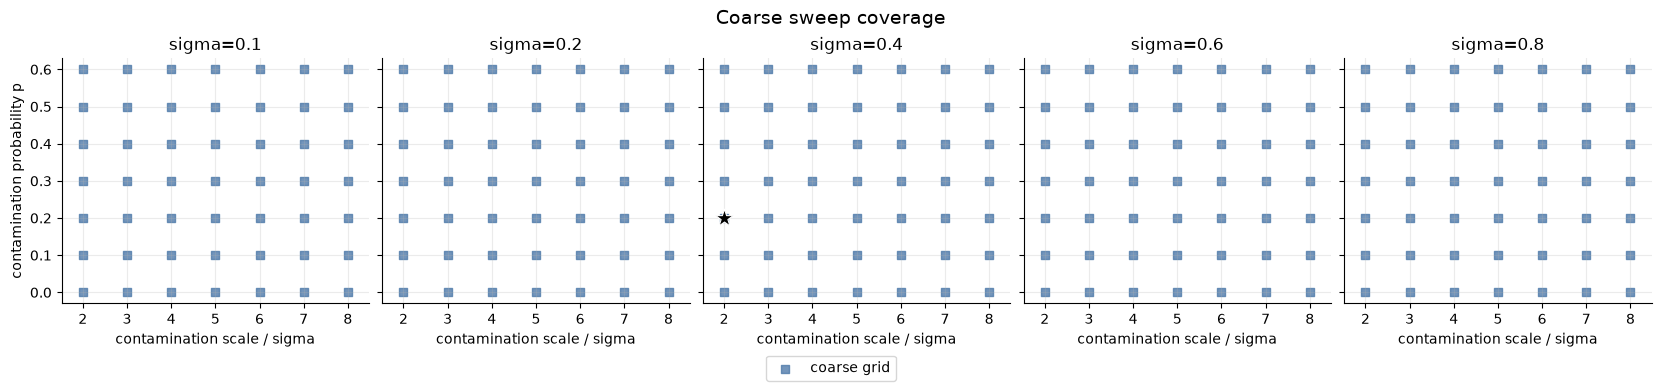

In [12]:
def plot_sweep_coverage(parameter_grid, title="Coarse sweep coverage"):
    sigmas = np.asarray(sorted(parameter_grid["sigma"].unique()), dtype=float)
    fig, axes = plt.subplots(1, len(sigmas), figsize=(3.3 * len(sigmas), 3.8), sharey=True, constrained_layout=True)
    axes = np.atleast_1d(axes)

    for ax, sigma_value in zip(axes, sigmas):
        panel = parameter_grid.loc[np.isclose(parameter_grid["sigma"], sigma_value)]
        ax.scatter(
            panel["contamination_scale"] / panel["sigma"],
            panel["contamination_probability"],
            s=26,
            marker="s",
            color="#4C78A8",
            alpha=0.78,
            label="coarse grid",
        )
        if np.isclose(sigma_value, CURRENT_SIGMA):
            ax.scatter(
                [CURRENT_CONTAMINATION_SCALE / CURRENT_SIGMA],
                [CURRENT_CONTAMINATION_PROB],
                marker="*",
                s=180,
                color="black",
                edgecolor="white",
                linewidth=0.8,
                label="sweep reference",
                zorder=5,
            )
        ax.set_title(f"sigma={sigma_value:g}")
        ax.set_xlabel("contamination scale / sigma")
        ax.set_xticks(contamination_scale_ratio_grid)
        ax.set_xticklabels([f"{value:g}" for value in contamination_scale_ratio_grid])
        ax.set_ylim(-0.03, 0.63)
        ax.set_yticks(contamination_prob_grid)
        ax.margins(x=0.08)

    axes[0].set_ylabel("contamination probability p")
    handles, labels = axes[-1].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.legend(by_label.values(), by_label.keys(), loc="outside lower center", ncol=2)
    fig.suptitle(title, fontsize=14)
    return fig, axes


plot_sweep_coverage(coarse_parameter_grid)
plt.show()


## Surface plotting helpers


In [13]:
METHOD_COLORS = {"linear": "#4C78A8", "robust": "#E45756"}


def coarse_surface_for_plot(surface_frame):
    return surface_frame.loc[surface_frame["grid_level"] == "coarse"].copy()


def pivot_metric(panel, metric_column):
    panel = panel.copy()
    panel["contamination_scale_ratio"] = panel["contamination_scale"] / panel["sigma"]
    table = panel.pivot_table(
        index="contamination_probability",
        columns="contamination_scale_ratio",
        values=metric_column,
        aggfunc="first",
    )
    table = table.sort_index().sort_index(axis=1)
    return table


def plot_method_heatmaps(metric, title, colorbar_label=None):
    metric_column = f"{metric}_median"
    plot_frame = coarse_surface_for_plot(surface_summary)
    methods = ["linear", "robust"]
    sigmas = np.asarray(sorted(plot_frame["sigma"].unique()), dtype=float)
    values = plot_frame[metric_column].to_numpy(dtype=float)
    positive = values[np.isfinite(values) & (values > 0)]
    norm = LogNorm(vmin=float(np.min(positive)), vmax=float(np.max(positive)))

    fig, axes = plt.subplots(
        len(methods),
        len(sigmas),
        figsize=(3.35 * len(sigmas), 6.3),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    last_mesh = None
    for row_index, method in enumerate(methods):
        for col_index, sigma_value in enumerate(sigmas):
            ax = axes[row_index, col_index]
            panel = plot_frame.loc[
                (plot_frame["method"] == method)
                & np.isclose(plot_frame["sigma"], sigma_value)
            ]
            table = pivot_metric(panel, metric_column)
            x_centers = table.columns.to_numpy(dtype=float)
            y_centers = table.index.to_numpy(dtype=float)
            last_mesh = ax.pcolormesh(
                centers_to_edges(x_centers),
                centers_to_edges(y_centers),
                table.to_numpy(dtype=float),
                cmap="viridis",
                norm=norm,
                shading="auto",
            )

            if np.isclose(sigma_value, CURRENT_SIGMA):
                ax.scatter(
                    [CURRENT_CONTAMINATION_SCALE / CURRENT_SIGMA],
                    [CURRENT_CONTAMINATION_PROB],
                    marker="*",
                    s=95,
                    color="black",
                    edgecolor="white",
                    linewidth=0.7,
                )
            ax.set_title(f"{method}, sigma={sigma_value:g}")
            ax.set_xticks(contamination_scale_ratio_grid)
            ax.set_xticklabels([f"{value:g}" for value in contamination_scale_ratio_grid])
            if col_index == 0:
                ax.set_ylabel("p")
            if row_index == len(methods) - 1:
                ax.set_xlabel("contamination scale / sigma")

    fig.colorbar(last_mesh, ax=axes.ravel().tolist(), label=colorbar_label or metric_column)
    fig.suptitle(title, fontsize=14)
    return fig, axes


def ratio_table_for_metric(metric):
    return method_ratio_surface(surface_summary, metric=metric, grid_level="coarse")


def plot_ratio_maps(metric, title):
    ratio = ratio_table_for_metric(metric)
    sigmas = np.asarray(sorted(ratio["sigma"].unique()), dtype=float)
    metric_values = ratio["log10_robust_linear_ratio"].to_numpy(dtype=float)
    limit = max(0.05, float(np.nanmax(np.abs(metric_values))))
    norm = TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit)

    fig, axes = plt.subplots(1, len(sigmas), figsize=(3.35 * len(sigmas), 3.7), sharey=True, constrained_layout=True)
    axes = np.atleast_1d(axes)
    last_mesh = None

    for ax, sigma_value in zip(axes, sigmas):
        panel = ratio.loc[np.isclose(ratio["sigma"], sigma_value)]
        panel = panel.copy()
        panel["contamination_scale_ratio"] = panel["contamination_scale"] / panel["sigma"]
        table = panel.pivot_table(
            index="contamination_probability",
            columns="contamination_scale_ratio",
            values="log10_robust_linear_ratio",
            aggfunc="first",
        ).sort_index().sort_index(axis=1)
        x_centers = table.columns.to_numpy(dtype=float)
        y_centers = table.index.to_numpy(dtype=float)
        z = table.to_numpy(dtype=float)
        last_mesh = ax.pcolormesh(
            centers_to_edges(x_centers),
            centers_to_edges(y_centers),
            z,
            cmap="coolwarm",
            norm=norm,
            shading="auto",
        )
        if np.nanmin(z) <= 0 <= np.nanmax(z):
            ax.contour(x_centers, y_centers, z, levels=[0.0], colors="black", linewidths=1.0)
        if np.isclose(sigma_value, CURRENT_SIGMA):
            ax.scatter(
                [CURRENT_CONTAMINATION_SCALE / CURRENT_SIGMA],
                [CURRENT_CONTAMINATION_PROB],
                marker="*",
                s=95,
                color="black",
                edgecolor="white",
                linewidth=0.7,
            )
        ax.set_title(f"sigma={sigma_value:g}")
        ax.set_xlabel("contamination scale / sigma")
        ax.set_xticks(contamination_scale_ratio_grid)
        ax.set_xticklabels([f"{value:g}" for value in contamination_scale_ratio_grid])

    axes[0].set_ylabel("p")
    fig.colorbar(last_mesh, ax=axes.ravel().tolist(), label="log10(robust / linear)")
    fig.suptitle(title, fontsize=14)
    return fig, axes


def baseline_degradation_frame(metric):
    metric_column = f"{metric}_median"
    coarse = coarse_surface_for_plot(surface_summary)
    baseline = coarse.loc[np.isclose(coarse["contamination_probability"], 0.0), [
        "method",
        "sigma",
        "contamination_scale",
        metric_column,
    ]].rename(columns={metric_column: "baseline_value"})
    merged = coarse.merge(
        baseline,
        on=["method", "sigma", "contamination_scale"],
        how="left",
        validate="many_to_one",
    )
    merged["degradation_ratio"] = merged[metric_column] / merged["baseline_value"]
    merged["log2_degradation_ratio"] = np.log2(np.maximum(merged["degradation_ratio"], 1e-12))
    return merged


def plot_baseline_degradation_maps(metric, title):
    degradation = baseline_degradation_frame(metric)
    methods = ["linear", "robust"]
    sigmas = np.asarray(sorted(degradation["sigma"].unique()), dtype=float)
    values = degradation["log2_degradation_ratio"].to_numpy(dtype=float)
    limit = max(1.0, float(np.nanmax(np.abs(values))))
    norm = TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit)

    fig, axes = plt.subplots(
        len(methods),
        len(sigmas),
        figsize=(3.35 * len(sigmas), 6.3),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    last_mesh = None
    for row_index, method in enumerate(methods):
        for col_index, sigma_value in enumerate(sigmas):
            ax = axes[row_index, col_index]
            panel = degradation.loc[
                (degradation["method"] == method)
                & np.isclose(degradation["sigma"], sigma_value)
            ]
            panel = panel.copy()
            panel["contamination_scale_ratio"] = panel["contamination_scale"] / panel["sigma"]
            table = panel.pivot_table(
                index="contamination_probability",
                columns="contamination_scale_ratio",
                values="log2_degradation_ratio",
                aggfunc="first",
            ).sort_index().sort_index(axis=1)
            x_centers = table.columns.to_numpy(dtype=float)
            y_centers = table.index.to_numpy(dtype=float)
            z = table.to_numpy(dtype=float)
            last_mesh = ax.pcolormesh(
                centers_to_edges(x_centers),
                centers_to_edges(y_centers),
                z,
                cmap="RdYlBu_r",
                norm=norm,
                shading="auto",
            )
            levels = [level for level in [1.0, 2.0, 3.0] if np.nanmin(z) <= level <= np.nanmax(z)]
            if levels:
                contour = ax.contour(x_centers, y_centers, z, levels=levels, colors="black", linewidths=0.85)
                ax.clabel(contour, fmt={1.0: "2x", 2.0: "4x", 3.0: "8x"}, fontsize=7)
            if np.isclose(sigma_value, CURRENT_SIGMA):
                ax.scatter(
                    [CURRENT_CONTAMINATION_SCALE / CURRENT_SIGMA],
                    [CURRENT_CONTAMINATION_PROB],
                    marker="*",
                    s=95,
                    color="black",
                    edgecolor="white",
                    linewidth=0.7,
                )
            ax.set_title(f"{method}, sigma={sigma_value:g}")
            ax.set_xticks(contamination_scale_ratio_grid)
            ax.set_xticklabels([f"{value:g}" for value in contamination_scale_ratio_grid])
            if col_index == 0:
                ax.set_ylabel("p")
            if row_index == len(methods) - 1:
                ax.set_xlabel("contamination scale / sigma")

    fig.colorbar(last_mesh, ax=axes.ravel().tolist(), label=f"log2({metric} / p=0 baseline)")
    fig.suptitle(title, fontsize=14)
    return fig, axes


## Linear and robust error surfaces


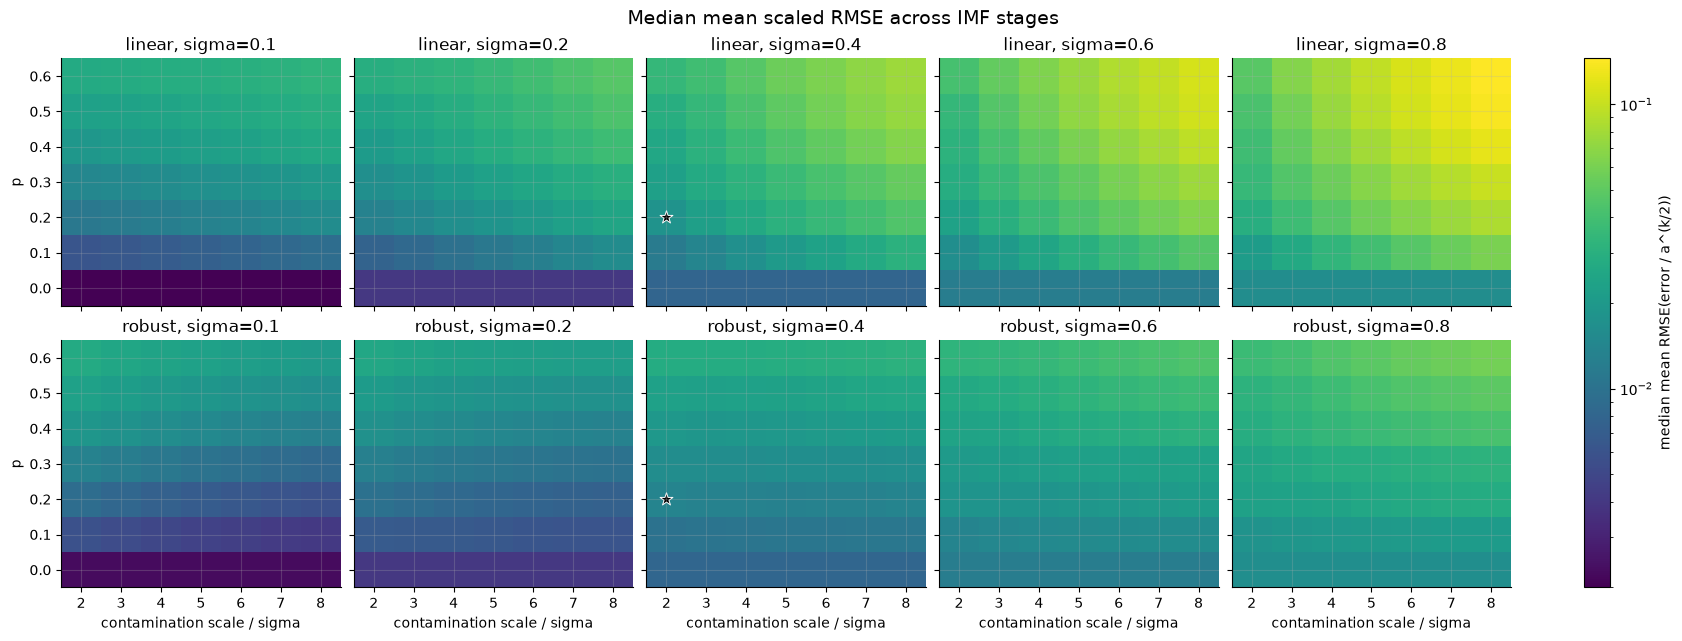

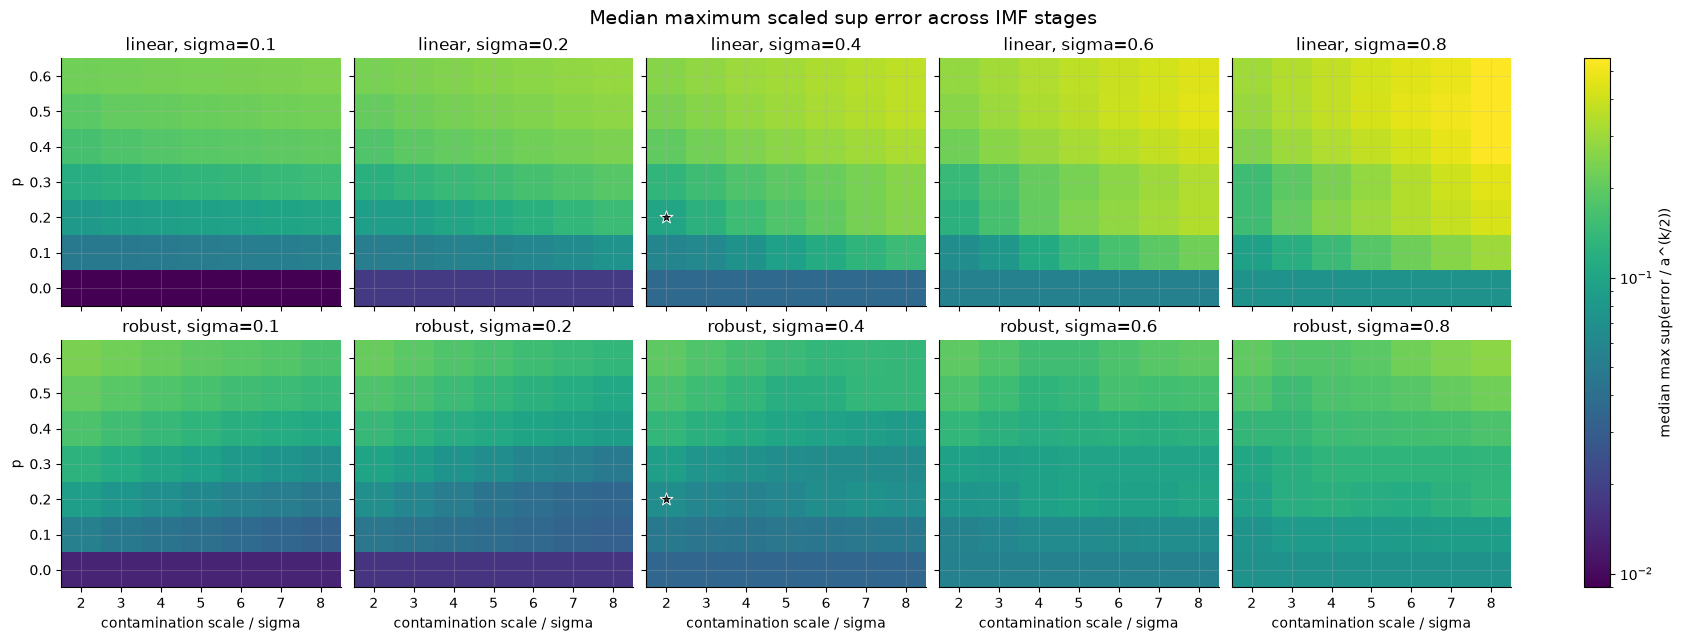

In [14]:
plot_method_heatmaps(
    "mean_scaled_rmse",
    "Median mean scaled RMSE across IMF stages",
    colorbar_label="median mean RMSE(error / a^(k/2))",
)
plt.show()

plot_method_heatmaps(
    "max_scaled_sup_error",
    "Median maximum scaled sup error across IMF stages",
    colorbar_label="median max sup(error / a^(k/2))",
)
plt.show()


## Robust-vs-linear ratio maps


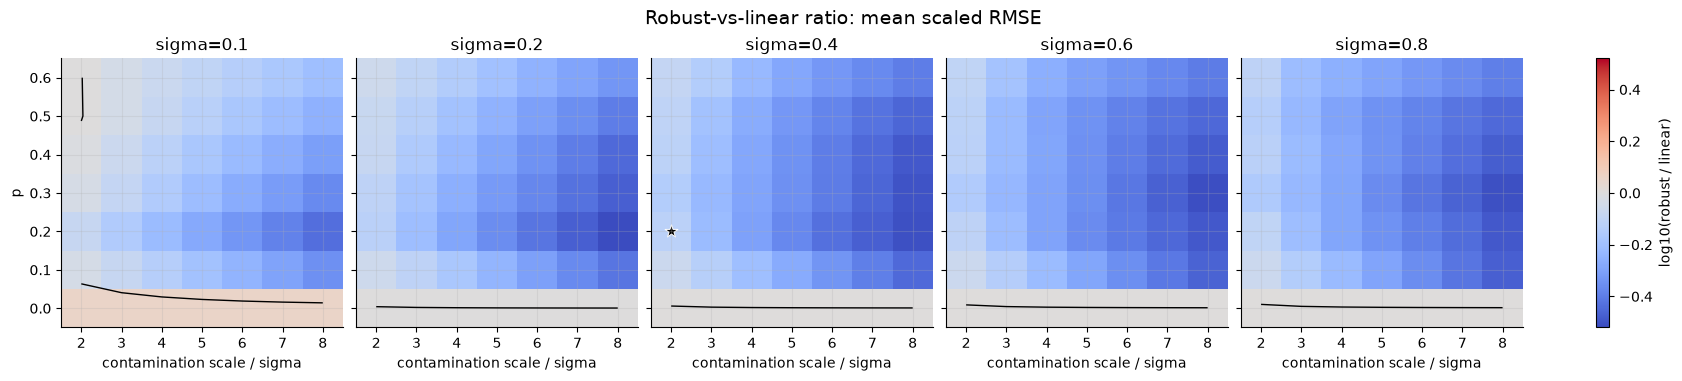

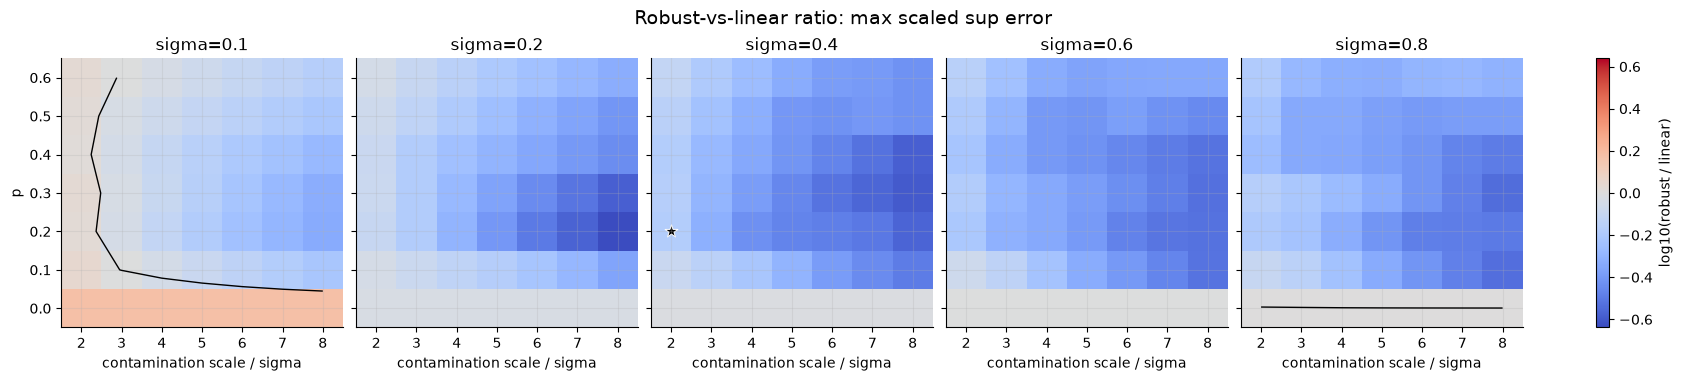

In [15]:
plot_ratio_maps(
    "mean_scaled_rmse",
    "Robust-vs-linear ratio: mean scaled RMSE",
)
plt.show()

plot_ratio_maps(
    "max_scaled_sup_error",
    "Robust-vs-linear ratio: max scaled sup error",
)
plt.show()


## Baseline-relative degradation maps


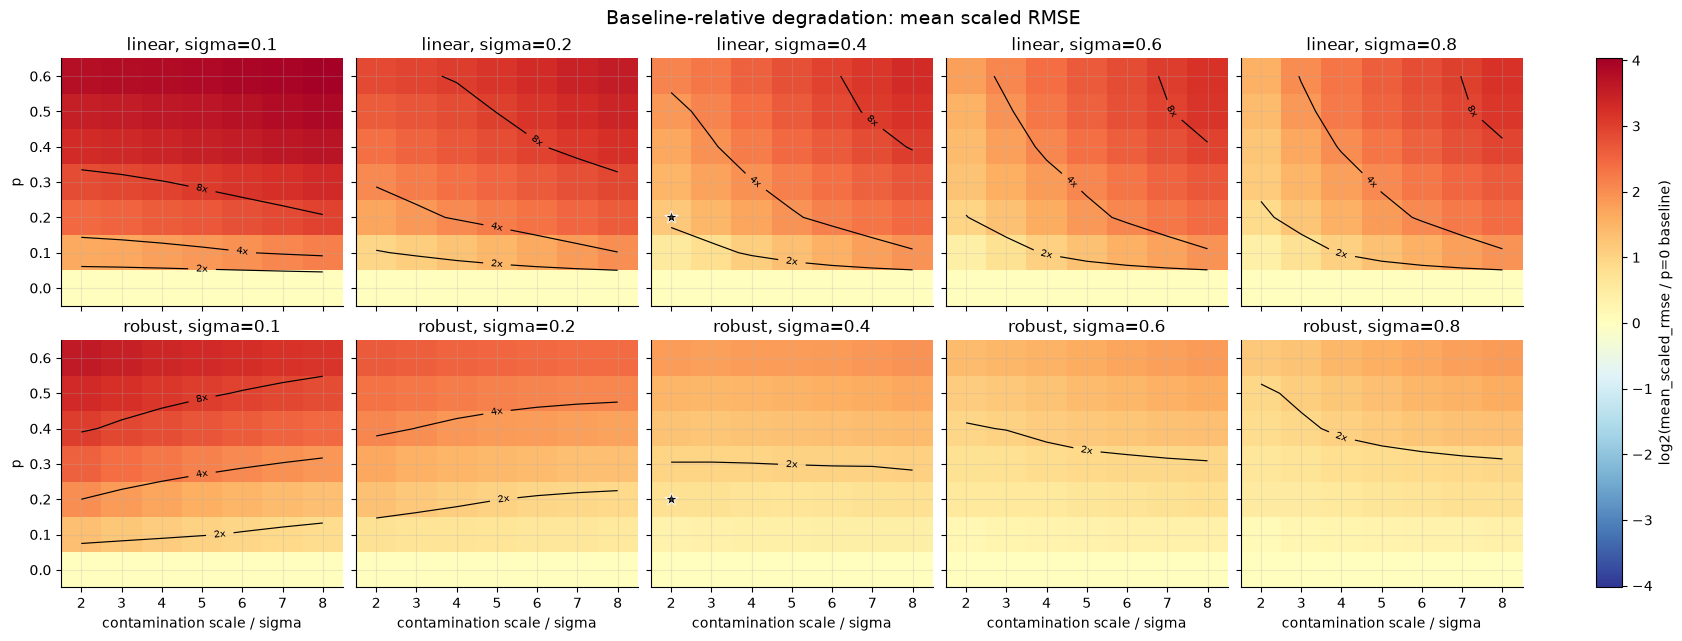

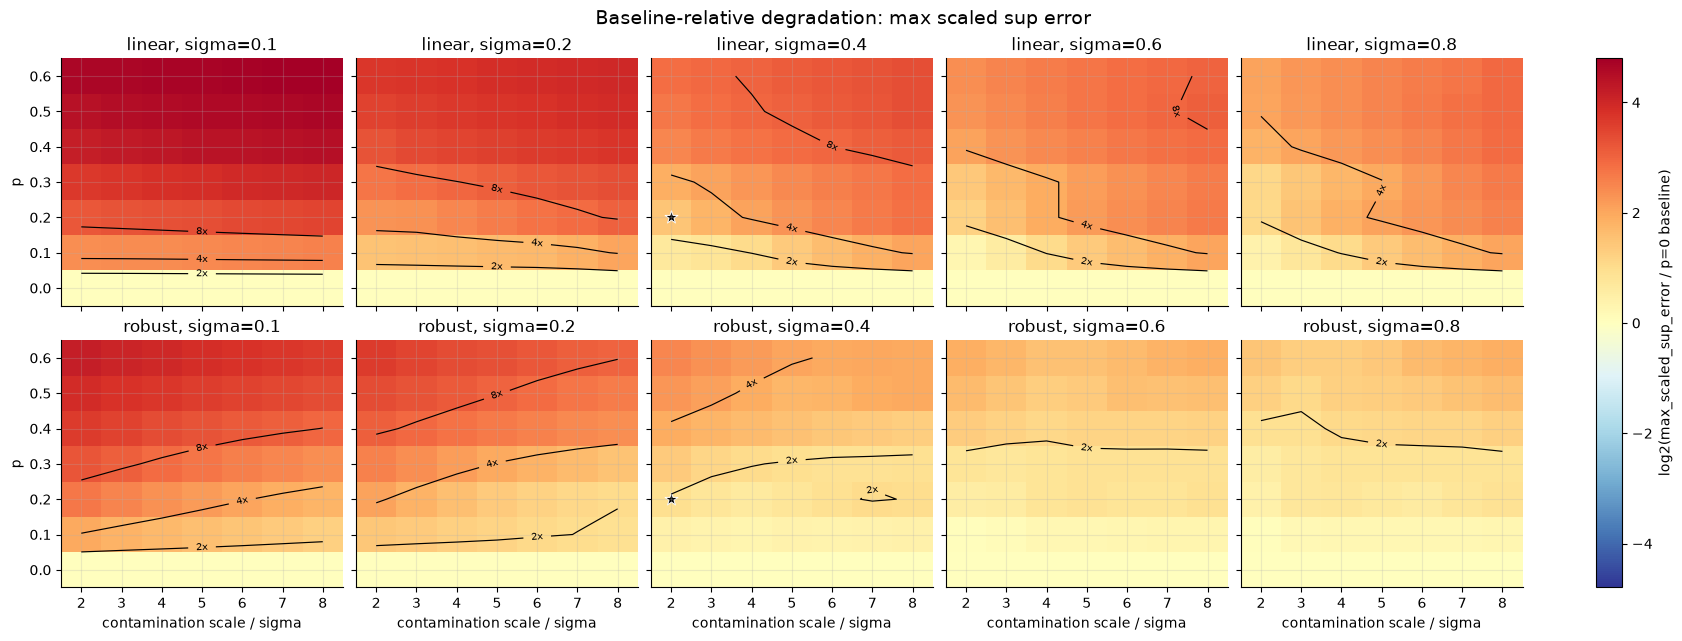

In [16]:
plot_baseline_degradation_maps(
    "mean_scaled_rmse",
    "Baseline-relative degradation: mean scaled RMSE",
)
plt.show()

plot_baseline_degradation_maps(
    "max_scaled_sup_error",
    "Baseline-relative degradation: max scaled sup error",
)
plt.show()


## Current-setting slices


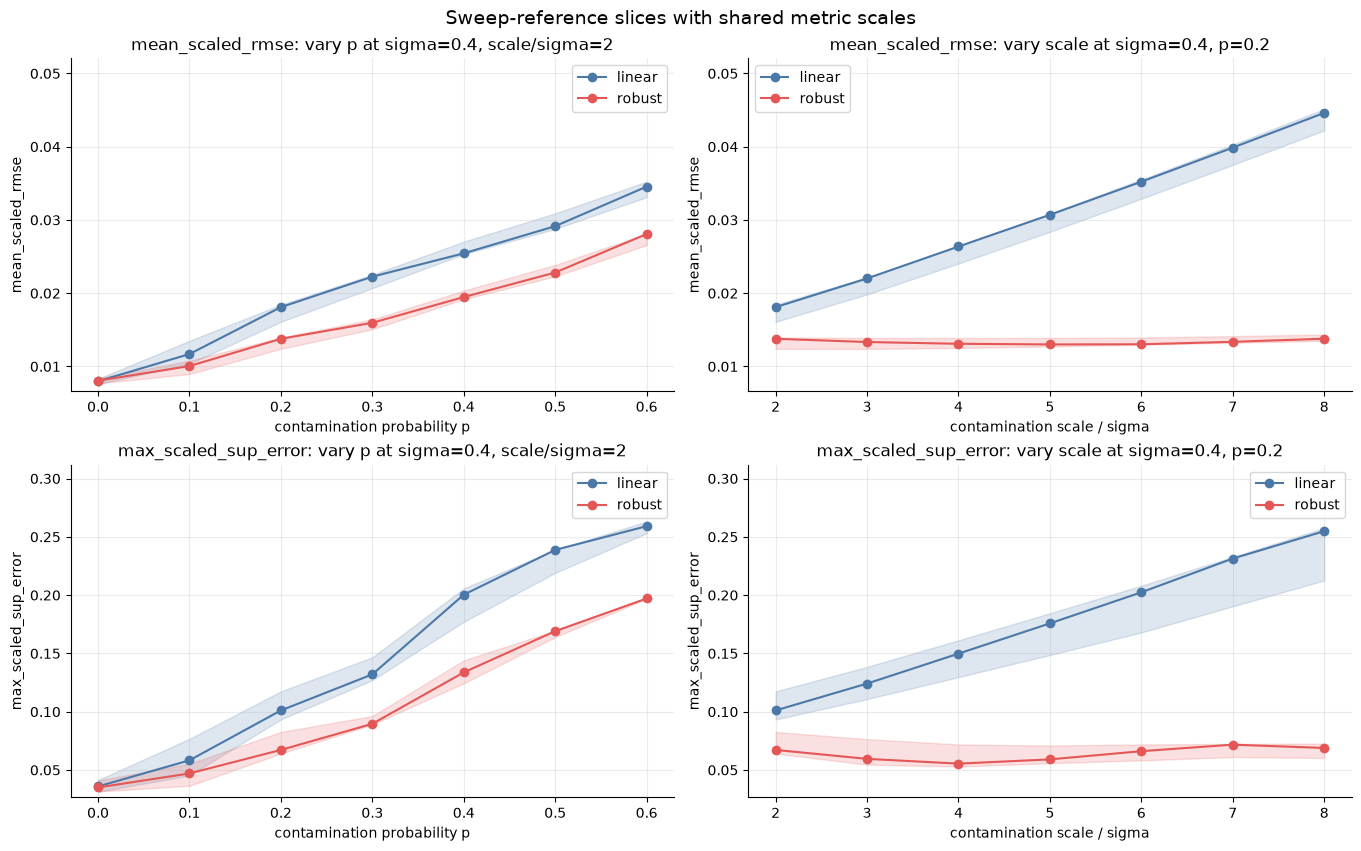

In [17]:
def summarize_slice(frame, varying_column, fixed_filters, metric):
    mask = np.ones(len(frame), dtype=bool)
    for column, value in fixed_filters.items():
        mask &= np.isclose(frame[column].to_numpy(dtype=float), float(value))
    filtered = frame.loc[mask].copy()
    rows = []
    for (method, value), group in filtered.groupby(["method", varying_column], sort=True):
        metric_values = group[metric].to_numpy(dtype=float)
        rows.append({
            "method": method,
            varying_column: float(value),
            "median": float(np.median(metric_values)),
            "q25": float(np.quantile(metric_values, 0.25)),
            "q75": float(np.quantile(metric_values, 0.75)),
        })
    return pd.DataFrame(rows)


def plot_current_setting_slices(metrics=("mean_scaled_rmse", "max_scaled_sup_error")):
    fig, axes = plt.subplots(len(metrics), 2, figsize=(13.5, 4.2 * len(metrics)), constrained_layout=True)
    axes = np.atleast_2d(axes)

    for row_index, metric in enumerate(metrics):
        p_slice = summarize_slice(
            aggregate_metrics,
            "contamination_probability",
            {
                "sigma": CURRENT_SIGMA,
                "contamination_scale": CURRENT_CONTAMINATION_SCALE,
            },
            metric,
        )
        scale_slice = summarize_slice(
            aggregate_metrics,
            "contamination_scale",
            {
                "sigma": CURRENT_SIGMA,
                "contamination_probability": CURRENT_CONTAMINATION_PROB,
            },
            metric,
        )
        y_values = []

        for method, group in p_slice.groupby("method"):
            group = group.sort_values("contamination_probability")
            y_values.extend([group["median"], group["q25"], group["q75"]])
            ax = axes[row_index, 0]
            ax.plot(
                group["contamination_probability"],
                group["median"],
                marker="o",
                color=METHOD_COLORS[method],
                label=method,
            )
            ax.fill_between(
                group["contamination_probability"],
                group["q25"],
                group["q75"],
                color=METHOD_COLORS[method],
                alpha=0.18,
            )

        for method, group in scale_slice.groupby("method"):
            group = group.sort_values("contamination_scale")
            y_values.extend([group["median"], group["q25"], group["q75"]])
            ax = axes[row_index, 1]
            ax.plot(
                group["contamination_scale"] / CURRENT_SIGMA,
                group["median"],
                marker="o",
                color=METHOD_COLORS[method],
                label=method,
            )
            ax.fill_between(
                group["contamination_scale"] / CURRENT_SIGMA,
                group["q25"],
                group["q75"],
                color=METHOD_COLORS[method],
                alpha=0.18,
            )

        y_limits = positive_log_limits(*y_values)
        for ax in axes[row_index, :]:
            ax.set_ylim(*y_limits)
            # ax.set_yscale("log")
            ax.legend()

        axes[row_index, 0].set_title(f"{metric}: vary p at sigma={CURRENT_SIGMA:g}, scale/sigma={CURRENT_CONTAMINATION_SCALE / CURRENT_SIGMA:g}")
        axes[row_index, 0].set_xlabel("contamination probability p")
        axes[row_index, 0].set_ylabel(metric)

        axes[row_index, 1].set_title(f"{metric}: vary scale at sigma={CURRENT_SIGMA:g}, p={CURRENT_CONTAMINATION_PROB:g}")
        axes[row_index, 1].set_xlabel("contamination scale / sigma")
        axes[row_index, 1].set_ylabel(metric)

    fig.suptitle("Sweep-reference slices with shared metric scales", fontsize=14)
    return fig, axes


plot_current_setting_slices()
plt.show()


## Representative detailed cases


In [18]:
def choose_repeat_for_parameter(params, metric="mean_scaled_rmse"):
    mask = (
        np.isclose(aggregate_metrics["sigma"], params["sigma"])
        & np.isclose(aggregate_metrics["contamination_probability"], params["contamination_probability"])
        & np.isclose(aggregate_metrics["contamination_scale"], params["contamination_scale"])
    )
    subset = aggregate_metrics.loc[mask]
    repeat_scores = (
        subset.groupby("repeat", as_index=False)[metric]
        .mean()
        .sort_values("repeat")
    )
    median_score = repeat_scores[metric].median()
    return int(repeat_scores.iloc[(repeat_scores[metric] - median_score).abs().argmin()]["repeat"])


def select_representative_parameters():
    ratio = ratio_table_for_metric("mean_scaled_rmse")
    current = {
        "case_label": "current setting",
        "sigma": CURRENT_SIGMA,
        "contamination_probability": CURRENT_CONTAMINATION_PROB,
        "contamination_scale": CURRENT_CONTAMINATION_SCALE,
        "selection_reason": "review baseline",
    }

    nonzero = ratio.loc[ratio["contamination_probability"] > 0].copy()
    robust_favorable = nonzero.sort_values("log10_robust_linear_ratio").iloc[0]
    linear_favorable = nonzero.sort_values("log10_robust_linear_ratio", ascending=False).iloc[0]

    selected = [current]
    for label, reason, row in [
        ("robust favorable", "lowest robust/linear mean scaled RMSE", robust_favorable),
        ("linear favorable or high degradation", "highest robust/linear mean scaled RMSE", linear_favorable),
    ]:
        selected.append({
            "case_label": label,
            "sigma": float(row["sigma"]),
            "contamination_probability": float(row["contamination_probability"]),
            "contamination_scale": float(row["contamination_scale"]),
            "selection_reason": reason,
        })

    frame = pd.DataFrame(selected)
    frame = frame.drop_duplicates(subset=["sigma", "contamination_probability", "contamination_scale"], keep="first")

    if len(frame) < 3:
        degradation = baseline_degradation_frame("mean_scaled_rmse")
        high = degradation.sort_values("log2_degradation_ratio", ascending=False).iloc[0]
        frame = pd.concat([
            frame,
            pd.DataFrame([{
                "case_label": "high degradation",
                "sigma": float(high["sigma"]),
                "contamination_probability": float(high["contamination_probability"]),
                "contamination_scale": float(high["contamination_scale"]),
                "selection_reason": "largest baseline-relative degradation",
            }]),
        ], ignore_index=True).drop_duplicates(subset=["sigma", "contamination_probability", "contamination_scale"], keep="first")

    frame["repeat"] = frame.apply(lambda row: choose_repeat_for_parameter(row), axis=1)
    return frame.reset_index(drop=True)


representative_cases = select_representative_parameters()
representative_cases


,case_label,sigma,contamination_probability,contamination_scale,selection_reason,repeat
0,current setting,0.4,0.2,0.8,review baseline,1
1,robust favorable,0.2,0.2,1.6,lowest robust/linear mean scaled RMSE,0
2,linear favorable or high degradation,0.1,0.5,0.2,highest robust/linear mean scaled RMSE,2


## Representative stage trends and signed-error boxplots


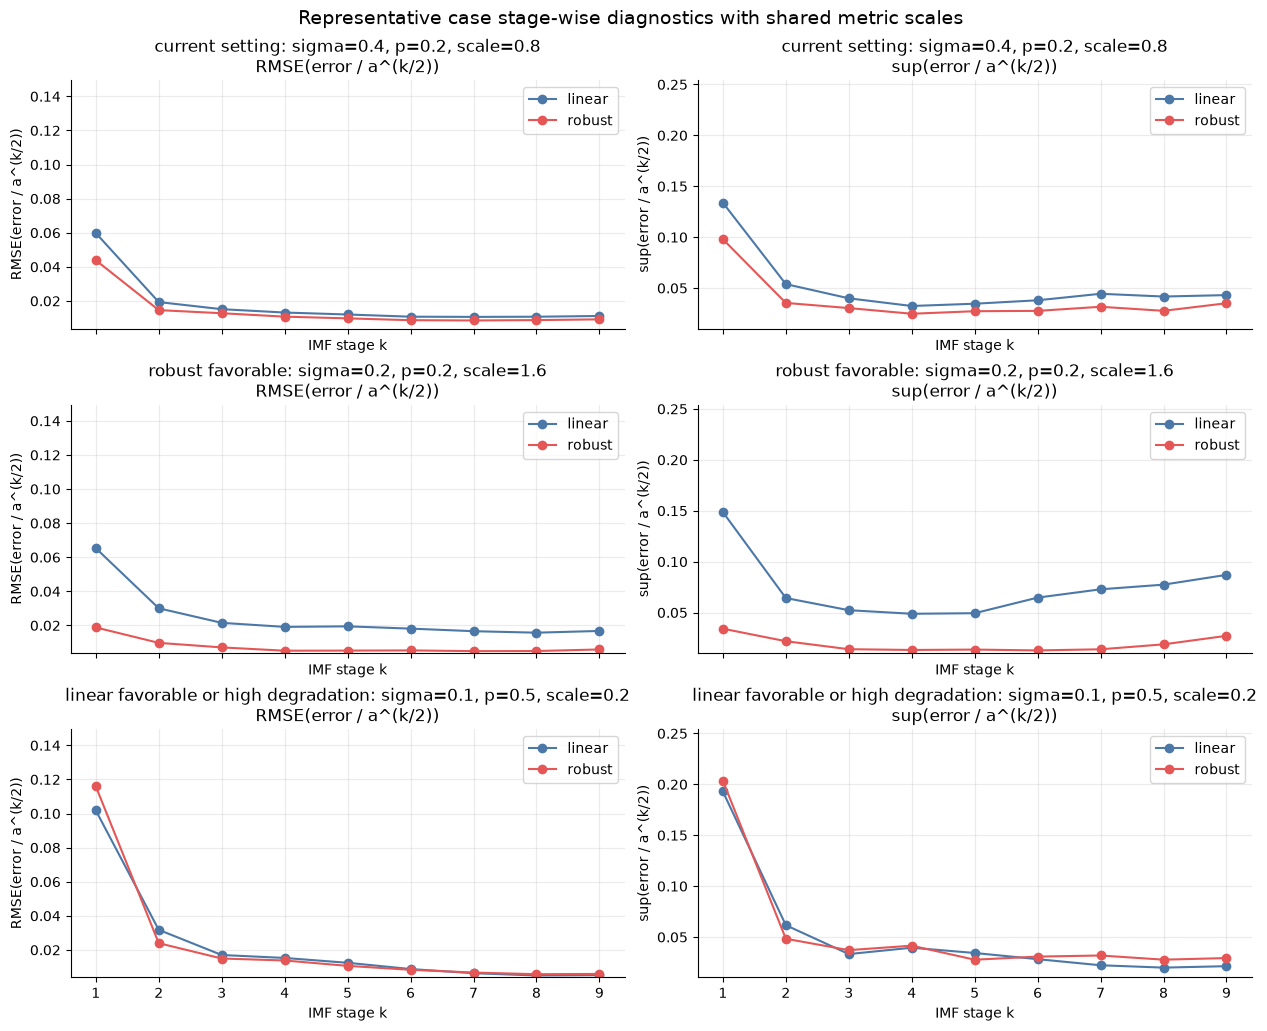

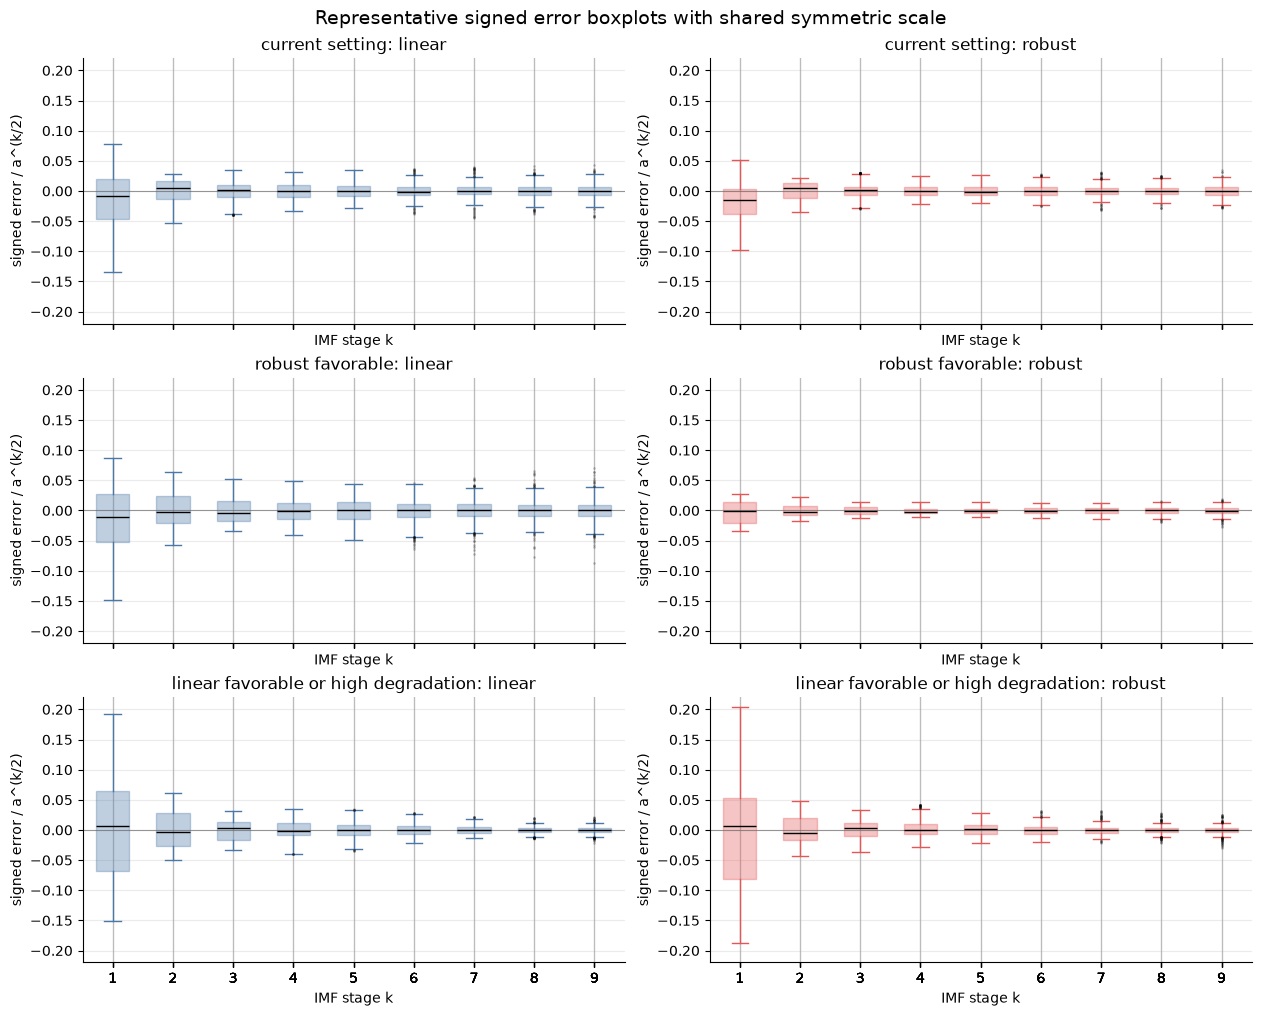

In [19]:
def error_value_frame(case_label, method, trial_row, reference_result, calculated_result):
    frames = []
    for stage_index, window_size in enumerate(window_sizes, start=1):
        reference_imf = reference_result["imfs"][stage_index - 1]
        calculated_imf = calculated_result["imfs"][stage_index - 1]
        error = calculated_imf - reference_imf
        scaled_error = scale_error_by_stage(error, stage_index)
        for scale_label, values in [("raw", error), ("a^(k/2)", scaled_error)]:
            frames.append(pd.DataFrame({
                "case_label": case_label,
                "method": method,
                "sigma": float(trial_row["sigma"]),
                "contamination_probability": float(trial_row["contamination_probability"]),
                "contamination_scale": float(trial_row["contamination_scale"]),
                "repeat": int(trial_row["repeat"]),
                "stage": stage_index,
                "window_size": window_size,
                "scale": scale_label,
                "t": t,
                "error_value": values,
            }))
    return pd.concat(frames, ignore_index=True)


def run_representative_case(row):
    trial_row = {
        "trial_id": f"detail|{row.case_label}|repeat={int(row.repeat)}",
        "grid_level": "detail",
        "sigma": float(row.sigma),
        "contamination_probability": float(row.contamination_probability),
        "contamination_scale": float(row.contamination_scale),
        "repeat": int(row.repeat),
    }
    observed_signal, noise_info = generate_coupled_observation(
        x_clean,
        sigma=trial_row["sigma"],
        contamination_prob=trial_row["contamination_probability"],
        contamination_scale=trial_row["contamination_scale"],
        repeat=trial_row["repeat"],
    )

    case_stage_rows = []
    case_value_frames = []
    for method in ["linear", "robust"]:
        if method == "linear":
            calculated_result = linear_imf_with_history(observed_signal, window_sizes)
        else:
            calculated_result = robust_gd_imf_with_history(
                observed_signal,
                window_sizes,
                H=2.0 * trial_row["sigma"],
                grid=lookup_grid,
                max_iter=60,
                tol=1e-6,
                max_workers=DEFAULT_MAX_WORKERS,
            )
        reference_result = clean_references[method][trial_row["sigma"]]
        rows, _ = summarize_result_against_reference(
            trial_row=trial_row,
            method=method,
            reference_result=reference_result,
            calculated_result=calculated_result,
            observed_signal=observed_signal,
            noise_info=noise_info,
        )
        for item in rows:
            item["case_label"] = row.case_label
            item["selection_reason"] = row.selection_reason
        case_stage_rows.extend(rows)
        case_value_frames.append(
            error_value_frame(row.case_label, method, trial_row, reference_result, calculated_result)
        )

    return pd.DataFrame(case_stage_rows), pd.concat(case_value_frames, ignore_index=True)


detail_parts = [run_representative_case(row) for row in representative_cases.itertuples(index=False)]
detail_stage_summary = pd.concat([part[0] for part in detail_parts], ignore_index=True)
error_values = pd.concat([part[1] for part in detail_parts], ignore_index=True)


def plot_representative_stage_trends():
    metrics = [
        ("scaled_error_rmse", "RMSE(error / a^(k/2))"),
        ("scaled_sup_error", "sup(error / a^(k/2))"),
    ]
    metric_limits = {
        metric: positive_log_limits(detail_stage_summary[metric])
        for metric, _ in metrics
    }
    cases = representative_cases["case_label"].tolist()
    fig, axes = plt.subplots(len(cases), len(metrics), figsize=(12.5, 3.4 * len(cases)), sharex=True, constrained_layout=True)
    axes = np.atleast_2d(axes)

    for row_index, case_label in enumerate(cases):
        case_frame = detail_stage_summary.loc[detail_stage_summary["case_label"] == case_label]
        title_bits = representative_cases.loc[representative_cases["case_label"] == case_label].iloc[0]
        for col_index, (metric, label) in enumerate(metrics):
            ax = axes[row_index, col_index]
            for method, group in case_frame.groupby("method"):
                group = group.sort_values("stage")
                ax.plot(
                    group["stage"],
                    group[metric],
                    marker="o",
                    color=METHOD_COLORS[method],
                    label=method,
                )
            ax.set_title(
                f"{case_label}: sigma={title_bits.sigma:g}, p={title_bits.contamination_probability:g}, scale={title_bits.contamination_scale:g}\n{label}"
            )
            ax.set_xlabel("IMF stage k")
            ax.set_ylabel(label)
            # ax.set_yscale("log")
            ax.set_ylim(*metric_limits[metric])
            ax.set_xticks(np.arange(1, len(window_sizes) + 1))
            ax.legend()

    fig.suptitle("Representative case stage-wise diagnostics with shared metric scales", fontsize=14)
    return fig, axes


def plot_representative_error_boxplots(scale_label="a^(k/2)"):
    cases = representative_cases["case_label"].tolist()
    methods = ["linear", "robust"]
    scaled_values = error_values.loc[error_values["scale"] == scale_label, "error_value"].to_numpy(dtype=float)
    limit = 1.08 * float(np.nanmax(np.abs(scaled_values)))
    if not np.isfinite(limit) or limit <= 0:
        limit = 1.0

    fig, axes = plt.subplots(len(cases), len(methods), figsize=(12.5, 3.35 * len(cases)), sharex=True, constrained_layout=True)
    axes = np.atleast_2d(axes)

    for row_index, case_label in enumerate(cases):
        for col_index, method in enumerate(methods):
            ax = axes[row_index, col_index]
            panel = error_values.loc[
                (error_values["case_label"] == case_label)
                & (error_values["method"] == method)
                & (error_values["scale"] == scale_label)
            ]
            stages = np.asarray(sorted(panel["stage"].unique()), dtype=int)
            data = [panel.loc[panel["stage"] == stage, "error_value"].to_numpy(dtype=float) for stage in stages]
            boxplot = ax.boxplot(
                data,
                positions=stages,
                widths=0.55,
                patch_artist=True,
                tick_labels=[str(stage) for stage in stages],
                flierprops={"marker": ".", "markersize": 1.8, "alpha": 0.22},
                medianprops={"color": "black", "linewidth": 1.0},
            )
            for patch in boxplot["boxes"]:
                patch.set_facecolor(METHOD_COLORS[method])
                patch.set_alpha(0.35)
                patch.set_edgecolor(METHOD_COLORS[method])
            for whisker in boxplot["whiskers"]:
                whisker.set_color(METHOD_COLORS[method])
            for cap in boxplot["caps"]:
                cap.set_color(METHOD_COLORS[method])
            ax.axhline(0.0, color="#666666", linewidth=0.8, alpha=0.65)
            ax.set_ylim(-limit, limit)
            ax.set_title(f"{case_label}: {method}")
            ax.set_xlabel("IMF stage k")
            ax.set_ylabel(f"signed error / {scale_label}")

    fig.suptitle("Representative signed error boxplots with shared symmetric scale", fontsize=14)
    return fig, axes


plot_representative_stage_trends()
plt.show()

plot_representative_error_boxplots()
plt.show()


## Validation checks


In [20]:
expected_methods = {"linear", "robust"}
expected_coarse_parameter_points = len(sigma_grid) * len(contamination_prob_grid) * len(contamination_scale_ratio_grid)
expected_coarse_trials = expected_coarse_parameter_points * n_repeats
expected_aggregate_rows = expected_coarse_trials * len(expected_methods)
expected_stage_rows = expected_aggregate_rows * len(window_sizes)
expected_surface_rows = expected_coarse_parameter_points * len(expected_methods)

assert set(stage_error_summary["method"].unique()) == expected_methods
assert set(aggregate_metrics["method"].unique()) == expected_methods
assert set(stage_error_summary["grid_level"].unique()) == {"coarse"}
assert set(aggregate_metrics["grid_level"].unique()) == {"coarse"}
assert set(surface_summary["grid_level"].unique()) == {"coarse"}
assert stage_error_summary["stage"].nunique() == len(window_sizes)
assert set(np.round(coarse_aggregate_metrics["sigma"].unique(), 10)) == set(np.round(sigma_grid, 10))
assert set(np.round(coarse_aggregate_metrics["contamination_probability"].unique(), 10)) == set(np.round(contamination_prob_grid, 10))
for sigma_value in sigma_grid:
    sigma_rows = coarse_parameter_grid.loc[np.isclose(coarse_parameter_grid["sigma"], sigma_value)]
    observed_ratios = sigma_rows["contamination_scale"].to_numpy(dtype=float) / float(sigma_value)
    assert set(np.round(observed_ratios, 10)) == set(np.round(contamination_scale_ratio_grid, 10))
assert coarse_aggregate_metrics["repeat"].nunique() == n_repeats
assert len(coarse_parameter_grid) == expected_coarse_parameter_points == 245
assert len(coarse_trials) == expected_coarse_trials == 735
assert len(aggregate_metrics) == expected_aggregate_rows == 1470
assert len(stage_error_summary) == expected_stage_rows == 13230
assert len(surface_summary) == expected_surface_rows == 490
assert np.isfinite(stage_error_summary[["error_rmse", "scaled_error_rmse", "sup_error", "scaled_sup_error"]].to_numpy()).all()
assert np.isfinite(aggregate_metrics[SURFACE_METRICS].to_numpy()).all()
assert aggregate_metrics["reconstruction_max_abs_error"].max() < 1e-10
assert set(error_values["scale"].unique()) == {"raw", "a^(k/2)"}

# Confirm the masked pure-noise observation semantics for both generators.
_sem_y0, _sem_info0 = generate_observation(
    x_clean,
    sigma=0.2,
    contamination_prob=0.0,
    contamination_scale=0.6,
    rng=np.random.default_rng(12_345),
)
assert not np.any(_sem_info0["contamination_mask"])
assert np.allclose(_sem_y0, x_clean + _sem_info0["gaussian_noise"])

_sem_y1, _sem_info1 = generate_observation(
    x_clean,
    sigma=0.2,
    contamination_prob=1.0,
    contamination_scale=0.6,
    rng=np.random.default_rng(12_345),
)
assert np.all(_sem_info1["contamination_mask"])
assert np.allclose(_sem_y1, _sem_info1["gaussian_noise"] + _sem_info1["contamination"])

_coupled_y, _coupled_info = generate_coupled_observation(
    x_clean,
    sigma=CURRENT_SIGMA,
    contamination_prob=0.5,
    contamination_scale=CURRENT_CONTAMINATION_SCALE,
    repeat=CURRENT_REPEAT,
)
_coupled_mask = _coupled_info["contamination_mask"]
assert np.any(_coupled_mask) and np.any(~_coupled_mask)
assert np.allclose(
    _coupled_y[_coupled_mask],
    _coupled_info["gaussian_noise"][_coupled_mask] + _coupled_info["contamination"][_coupled_mask],
)
assert np.allclose(
    _coupled_y[~_coupled_mask],
    x_clean[~_coupled_mask] + _coupled_info["gaussian_noise"][~_coupled_mask],
)

validation_summary = pd.DataFrame([
    {"check": "methods", "value": ", ".join(sorted(expected_methods))},
    {"check": "coarse parameter points", "value": len(coarse_parameter_grid)},
    {"check": "coarse trials", "value": len(coarse_trials)},
    {"check": "aggregate metric rows", "value": len(aggregate_metrics)},
    {"check": "stage error rows", "value": len(stage_error_summary)},
    {"check": "surface summary rows", "value": len(surface_summary)},
    {"check": "detail signed-error rows", "value": len(error_values)},
    {"check": "max reconstruction error", "value": f"{aggregate_metrics['reconstruction_max_abs_error'].max():.3e}"},
    {"check": "masked observation semantics", "value": "passed"},
])

validation_summary


,check,value
0,methods,"linear, robust"
1,coarse parameter points,245
2,coarse trials,735
3,aggregate metric rows,1470
4,stage error rows,13230
5,surface summary rows,490
6,detail signed-error rows,108000
7,max reconstruction error,2.132e-14
8,masked observation semantics,passed
